# NB13: *P. aeruginosa* Virulence System Distribution Across Environments

**Project**: CF Protective Microbiome Formulation Design
**Goal**: Map the distribution of key PA virulence and biofilm systems across
isolation environments to understand which PA variants the formulation will encounter
in CF lungs — and whether metabolic competition targets are independent of virulence genotype.

## Key Systems Analyzed

| System | Genes | Significance |
|--------|-------|-------------|
| **T3SS effectors** | exoU, exoS, exoT, exoY | ExoU (cytotoxic phospholipase) vs ExoS (ADP-ribosyltransferase) — near-mutually exclusive, different killing mechanisms |
| **Biofilm polysaccharides** | pelA-G, pslA-O | Pel-only (PA14-like) vs Pel+Psl (PAO1-like) — different biofilm architecture and surface attachment |
| **Regulatory switch** | ladS, retS, gacS | Acute-vs-chronic infection switch; ladS mutation in PA14 locks acute virulence |

## Data Sources
- `kbase_ke_pangenome`: 6,760 PA genomes with bakta + eggNOG annotations and ncbi_env isolation metadata
- `protect_genomedepot`: 651 PROTECT PA genomes with gene-level annotations
- `~/protect/gold/`: Patient metadata (clinical status A–D)

**Requires**: BERDL Spark access

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data')
FIGS = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

PA_CLADE = 's__Pseudomonas_aeruginosa--RS_GCF_001457615.1'

# Target genes
T3SS_EFFECTORS = ['exoU', 'exoS', 'exoT', 'exoY']
PEL_GENES = ['pelA', 'pelB', 'pelC', 'pelD', 'pelE', 'pelF', 'pelG']
PSL_GENES = ['pslA', 'pslB', 'pslC', 'pslD', 'pslE', 'pslF', 'pslG',
             'pslH', 'pslI', 'pslJ', 'pslK', 'pslL', 'pslM', 'pslN', 'pslO']
REGULATORS = ['ladS', 'retS', 'gacS', 'gacA']
ALL_TARGETS = T3SS_EFFECTORS + PEL_GENES + PSL_GENES + REGULATORS

# KEGG orthologs for psl (since gene names are under-annotated)
PSL_KEGG = {
    'K20997': 'pslA', 'K20998': 'pslE', 'K20999': 'pslF', 'K21000': 'pslG',
    'K21001': 'pslH', 'K21002': 'pslI', 'K21003': 'pslJ', 'K21004': 'pslK',
    'K21005': 'pslL'
}
# KEGG orthologs for pel
PEL_KEGG = {
    'K21006': 'pelA', 'K21007': 'pelB', 'K21008': 'pelC',
    'K21009': 'pelD', 'K21010': 'pelE', 'K21011': 'pelF', 'K21012': 'pelG'
}

print('Setup complete. Target genes:', len(ALL_TARGETS))

Setup complete. Target genes: 30


## 1. Pangenome: Virulence Gene Presence via Bakta Annotations

Query bakta_annotations for all PA genomes to detect T3SS effectors, pel/psl operons,
and regulatory genes. Use gene name matching for well-annotated genes, KEGG orthologs
for under-annotated psl operon.

In [2]:
# Query bakta annotations for target gene names
# bakta_annotations has: gene_cluster_id, gene, product, ec_number, kegg, uniref
target_genes_sql = "','".join(ALL_TARGETS)

print('Querying bakta annotations for target genes...')
bakta_hits = spark.sql(f"""
    SELECT ba.gene_cluster_id, ba.gene, ba.product, ba.kegg_orthology_id,
           CASE WHEN gc.is_core THEN 'core' WHEN gc.is_auxiliary THEN 'auxiliary' ELSE 'singleton' END AS core_auxiliary
    FROM kbase_ke_pangenome.bakta_annotations ba
    JOIN kbase_ke_pangenome.gene_cluster gc ON ba.gene_cluster_id = gc.gene_cluster_id
    WHERE gc.gtdb_species_clade_id = '{PA_CLADE}'
      AND ba.gene IN ('{target_genes_sql}')
""").toPandas()

print(f'Bakta hits: {len(bakta_hits)} gene clusters with target genes')
print(f'Genes found: {sorted(bakta_hits.gene.unique())}')

# Summarize
gene_summary = bakta_hits.groupby('gene').agg(
    n_clusters=('gene_cluster_id', 'nunique'),
    core_aux=('core_auxiliary', 'first'),
    product=('product', 'first')
).sort_index()
print('\nGene cluster summary:')
print(gene_summary.to_string())

Querying bakta annotations for target genes...


Bakta hits: 144 gene clusters with target genes
Genes found: ['exoS', 'exoT', 'exoU', 'exoY', 'gacS', 'ladS', 'pelA', 'pelB', 'pelC', 'pelD', 'pelE', 'pelF', 'pelG', 'pslA', 'pslC', 'pslD', 'pslE', 'pslF', 'pslG', 'pslH', 'pslI', 'pslJ', 'pslK', 'pslL', 'retS']

Gene cluster summary:
      n_clusters   core_aux                                                                      product
gene                                                                                                    
exoS           2  auxiliary                                                         Secreted exoenzyme S
exoT           3  auxiliary                                                                  Exoenzyme T
exoU           4  auxiliary                            type III secretion system effector cytotoxin ExoU
exoY           2  auxiliary                   type III secretion system effector ExoY, adenylate cyclase
gacS          11  auxiliary  DNA-binding response regulator in two-component regulato

In [3]:
# Map gene clusters to individual genomes via gene_genecluster_junction
# This tells us which genomes have which genes
target_cluster_ids = bakta_hits.gene_cluster_id.unique().tolist()
cluster_id_sql = "','".join(target_cluster_ids[:500])  # batch if needed

print(f'Mapping {len(target_cluster_ids)} gene clusters to genomes...')

# Query in batches if many clusters
all_mappings = []
batch_size = 200
for i in range(0, len(target_cluster_ids), batch_size):
    batch = target_cluster_ids[i:i+batch_size]
    batch_sql = "','".join(batch)
    batch_df = spark.sql(f"""
        SELECT ggj.gene_cluster_id, g.genome_id
        FROM kbase_ke_pangenome.gene_genecluster_junction ggj
        JOIN kbase_ke_pangenome.gene g ON ggj.gene_id = g.gene_id
        WHERE ggj.gene_cluster_id IN ('{batch_sql}')

    """).toPandas()
    all_mappings.append(batch_df)
    if (i // batch_size) % 5 == 0:
        print(f'  Batch {i//batch_size + 1}/{(len(target_cluster_ids)-1)//batch_size + 1}...')

genome_gene_map = pd.concat(all_mappings, ignore_index=True)
print(f'Genome-gene mappings: {len(genome_gene_map)} rows')
print(f'Unique genomes: {genome_gene_map.genome_id.nunique()}')

# Join with gene names
cluster_to_gene = bakta_hits[['gene_cluster_id', 'gene']].drop_duplicates()
genome_genes = genome_gene_map.merge(cluster_to_gene, on='gene_cluster_id')

# Create genome x gene presence matrix
gene_presence = genome_genes.groupby(['genome_id', 'gene']).size().unstack(fill_value=0)
gene_presence = (gene_presence > 0).astype(int)  # binary presence/absence

print(f'\nGene presence matrix: {gene_presence.shape[0]} genomes x {gene_presence.shape[1]} genes')
print(f'\nPer-gene prevalence:')
for gene in sorted(gene_presence.columns):
    n = gene_presence[gene].sum()
    pct = n / len(gene_presence) * 100
    print(f'  {gene}: {n} genomes ({pct:.1f}%)')

Mapping 144 gene clusters to genomes...


  Batch 1/1...
Genome-gene mappings: 131676 rows
Unique genomes: 6760

Gene presence matrix: 6760 genomes x 25 genes

Per-gene prevalence:
  exoS: 4941 genomes (73.1%)
  exoT: 6708 genomes (99.2%)
  exoU: 1797 genomes (26.6%)
  exoY: 6177 genomes (91.4%)
  gacS: 6731 genomes (99.6%)
  ladS: 33 genomes (0.5%)
  pelA: 6552 genomes (96.9%)
  pelB: 6700 genomes (99.1%)
  pelC: 6666 genomes (98.6%)
  pelD: 6712 genomes (99.3%)
  pelE: 6710 genomes (99.3%)
  pelF: 6749 genomes (99.8%)
  pelG: 6747 genomes (99.8%)
  pslA: 1 genomes (0.0%)
  pslC: 6328 genomes (93.6%)
  pslD: 6385 genomes (94.5%)
  pslE: 6429 genomes (95.1%)
  pslF: 6438 genomes (95.2%)
  pslG: 13 genomes (0.2%)
  pslH: 6477 genomes (95.8%)
  pslI: 6427 genomes (95.1%)
  pslJ: 6489 genomes (96.0%)
  pslK: 13 genomes (0.2%)
  pslL: 6456 genomes (95.5%)
  retS: 6670 genomes (98.7%)


In [4]:
# Supplement psl detection using KEGG orthologs from eggNOG
# psl genes are under-annotated by name but detectable via KEGG
psl_kegg_ids = list(PSL_KEGG.keys())
pel_kegg_ids = list(PEL_KEGG.keys())
all_kegg_ids = psl_kegg_ids + pel_kegg_ids
kegg_sql = "','".join(all_kegg_ids)

print('Querying eggNOG for psl/pel KEGG orthologs...')
kegg_hits = spark.sql(f"""
    SELECT gc.gene_cluster_id, ea.KEGG_ko
    FROM kbase_ke_pangenome.eggnog_mapper_annotations ea
    JOIN kbase_ke_pangenome.gene_cluster gc ON ea.query_name = gc.gene_cluster_id
    WHERE gc.gtdb_species_clade_id = '{PA_CLADE}'
      AND ea.KEGG_ko RLIKE '({"|".join(all_kegg_ids)})'
""").toPandas()

print(f'KEGG hits: {len(kegg_hits)} gene clusters')

# Map KEGG to gene names
kegg_to_gene = {**PSL_KEGG, **PEL_KEGG}
kegg_hits['gene_from_kegg'] = kegg_hits.KEGG_ko.apply(
    lambda x: next((kegg_to_gene[k] for k in kegg_to_gene if k in str(x)), None)
)
kegg_hits = kegg_hits[kegg_hits.gene_from_kegg.notna()]
print(f'Mapped to genes: {kegg_hits.gene_from_kegg.value_counts().to_dict()}')

# Map these clusters to genomes
kegg_cluster_ids = kegg_hits.gene_cluster_id.unique().tolist()
kegg_mappings = []
for i in range(0, len(kegg_cluster_ids), batch_size):
    batch = kegg_cluster_ids[i:i+batch_size]
    batch_sql = "','".join(batch)
    batch_df = spark.sql(f"""
        SELECT ggj.gene_cluster_id, g.genome_id
        FROM kbase_ke_pangenome.gene_genecluster_junction ggj
        JOIN kbase_ke_pangenome.gene g ON ggj.gene_id = g.gene_id
        WHERE ggj.gene_cluster_id IN ('{batch_sql}')

    """).toPandas()
    kegg_mappings.append(batch_df)

kegg_genome_map = pd.concat(kegg_mappings, ignore_index=True)
kegg_cluster_to_gene = kegg_hits[['gene_cluster_id', 'gene_from_kegg']].drop_duplicates()
kegg_genome_genes = kegg_genome_map.merge(kegg_cluster_to_gene, on='gene_cluster_id')

# Create KEGG-based presence matrix
kegg_presence = kegg_genome_genes.groupby(['genome_id', 'gene_from_kegg']).size().unstack(fill_value=0)
kegg_presence = (kegg_presence > 0).astype(int)

print(f'\nKEGG-based presence matrix: {kegg_presence.shape[0]} genomes x {kegg_presence.shape[1]} genes')
print(f'\nPer-gene prevalence (KEGG-based):')
for gene in sorted(kegg_presence.columns):
    n = kegg_presence[gene].sum()
    pct = n / len(kegg_presence) * 100
    print(f'  {gene}: {n} genomes ({pct:.1f}%)')

Querying eggNOG for psl/pel KEGG orthologs...


KEGG hits: 84 gene clusters
Mapped to genes: {'pelA': 26, 'pslI': 12, 'pelF': 10, 'pslG': 5, 'pelG': 5, 'pslA': 5, 'pelB': 4, 'pslH': 4, 'pslK': 3, 'pelE': 2, 'pslE': 2, 'pelD': 2, 'pslL': 1, 'pelC': 1, 'pslF': 1, 'pslJ': 1}



KEGG-based presence matrix: 6760 genomes x 16 genes

Per-gene prevalence (KEGG-based):
  pelA: 6608 genomes (97.8%)
  pelB: 6621 genomes (97.9%)
  pelC: 6645 genomes (98.3%)
  pelD: 6686 genomes (98.9%)
  pelE: 6693 genomes (99.0%)
  pelF: 6753 genomes (99.9%)
  pelG: 6740 genomes (99.7%)
  pslA: 6382 genomes (94.4%)
  pslE: 6429 genomes (95.1%)
  pslF: 6417 genomes (94.9%)
  pslG: 6468 genomes (95.7%)
  pslH: 6458 genomes (95.5%)
  pslI: 6426 genomes (95.1%)
  pslJ: 6475 genomes (95.8%)
  pslK: 6402 genomes (94.7%)
  pslL: 6502 genomes (96.2%)


In [5]:
# Merge bakta name-based and KEGG-based detections
combined = gene_presence.copy()

# Add KEGG-detected genes
for gene in kegg_presence.columns:
    if gene in combined.columns:
        shared_idx = combined.index.intersection(kegg_presence.index)
        combined.loc[shared_idx, gene] = (combined.loc[shared_idx, gene] | kegg_presence.loc[shared_idx, gene]).astype(int)
        new_idx = kegg_presence.index.difference(combined.index)
        if len(new_idx) > 0:
            new_rows = pd.DataFrame(0, index=new_idx, columns=combined.columns)
            new_rows[gene] = kegg_presence.loc[new_idx, gene]
            combined = pd.concat([combined, new_rows])
    else:
        combined[gene] = 0
        shared_idx = combined.index.intersection(kegg_presence.index)
        combined.loc[shared_idx, gene] = kegg_presence.loc[shared_idx, gene]

combined = combined.fillna(0).astype(int)
print(f'Combined presence matrix: {combined.shape[0]} genomes x {combined.shape[1]} genes')

# Map environment — query Spark directly for full coverage
print('Querying Spark for PA isolation sources...')
pa_env_spark = spark.sql(f"""
    SELECT g.genome_id, n.content AS isolation_source
    FROM kbase_ke_pangenome.genome g
    JOIN kbase_ke_pangenome.ncbi_env n ON g.ncbi_biosample_id = n.accession
    WHERE g.gtdb_species_clade_id = '{PA_CLADE}'
      AND n.harmonized_name = 'isolation_source'
""").toPandas()

def classify_pa_source(text):
    if pd.isna(text): return 'Unknown'
    t = str(text).lower()
    if 'cystic fibrosis' in t or 'cf ' in t or 'cf_' in t: return 'CF patient'
    if any(x in t for x in ['sputum','lung','respiratory','bronch','trachea','bal','bronchoalveolar','pneumonia','pulmonary']): return 'Lung/Respiratory'
    if any(x in t for x in ['throat','pharyn','nasal','sinus','ear','otitis']): return 'Upper Airway'
    if any(x in t for x in ['blood','wound','burn','urine','urinary','eye','cornea','abscess','hospital','ward','icu','clinical','patient','infection','feces']): return 'Other Clinical'
    if any(x in t for x in ['soil','water','river','marine','sediment','plant','rhizo','compost','drain','sink','shower']): return 'Environmental'
    if 'missing' in t or 'not applicable' in t or 'not collected' in t: return 'Unknown'
    return 'Other'

pa_env_spark['category'] = pa_env_spark.isolation_source.apply(classify_pa_source)

# Build env_map — strip RS_/GB_ prefix to match gene presence index
env_map = {}
for _, row in pa_env_spark.iterrows():
    gid = str(row.genome_id)
    env_map[gid] = row.category

combined['environment'] = combined.index.map(env_map).fillna('Unknown')
n_mapped = combined.environment.ne('Unknown').sum()
print(f'Environment coverage: {n_mapped}/{len(combined)} ({n_mapped/len(combined):.0%})')
print(combined.environment.value_counts().to_string())

Combined presence matrix: 6760 genomes x 25 genes
Querying Spark for PA isolation sources...


Environment coverage: 4769/6760 (71%)
environment
Unknown             1991
Other Clinical      1731
Lung/Respiratory    1505
Other                706
Environmental        370
CF patient           291
Upper Airway         166


## 2. T3SS Effector Typing: ExoU vs ExoS Across Environments

ExoU (cytotoxic phospholipase, rapid cell lysis) and ExoS (ADP-ribosyltransferase, slower
apoptotic effects) are near-mutually exclusive across PA. Their distribution by environment
reveals whether CF/lung PA is enriched for either effector type.

In [6]:
# Classify genomes by T3SS effector type
def classify_t3ss(row):
    has_u = row.get('exoU', 0) > 0
    has_s = row.get('exoS', 0) > 0
    if has_u and has_s:
        return 'ExoU+ExoS+'
    elif has_u:
        return 'ExoU+'
    elif has_s:
        return 'ExoS+'
    else:
        return 'Neither'

combined['t3ss_type'] = combined.apply(classify_t3ss, axis=1)

# Overall distribution
print('=== T3SS Effector Type Distribution (all PA genomes) ===')
t3ss_counts = combined.t3ss_type.value_counts()
total = len(combined)
for t, n in t3ss_counts.items():
    print(f'  {t}: {n} ({n/total:.1%})')

# By environment
env_order = ['CF patient', 'Lung/Respiratory', 'Upper Airway', 'Other Clinical', 'Environmental', 'Other', 'Unknown']
available_envs = [e for e in env_order if e in combined.environment.values]

print(f'\n=== T3SS Type by Environment ===')
t3ss_by_env = pd.crosstab(combined.environment, combined.t3ss_type, margins=True)
# Add percentage
for col in t3ss_by_env.columns:
    if col != 'All':
        t3ss_by_env[f'{col} %'] = (t3ss_by_env[col] / t3ss_by_env['All'] * 100).round(1)

print(t3ss_by_env.loc[available_envs + ['All']].to_string())

=== T3SS Effector Type Distribution (all PA genomes) ===
  ExoS+: 4837 (71.6%)
  ExoU+: 1693 (25.0%)
  Neither: 126 (1.9%)
  ExoU+ExoS+: 104 (1.5%)

=== T3SS Type by Environment ===
t3ss_type         ExoS+  ExoU+  ExoU+ExoS+  Neither   All  ExoS+ %  ExoU+ %  ExoU+ExoS+ %  Neither %
environment                                                                                         
CF patient          274     14           0        3   291     94.2      4.8           0.0        1.0
Lung/Respiratory   1226    248          12       19  1505     81.5     16.5           0.8        1.3
Upper Airway        139     22           2        3   166     83.7     13.3           1.2        1.8
Other Clinical     1085    572          50       24  1731     62.7     33.0           2.9        1.4
Environmental       231    128           2        9   370     62.4     34.6           0.5        2.4
Other               503    185           6       12   706     71.2     26.2           0.8        1.7
Unknown   

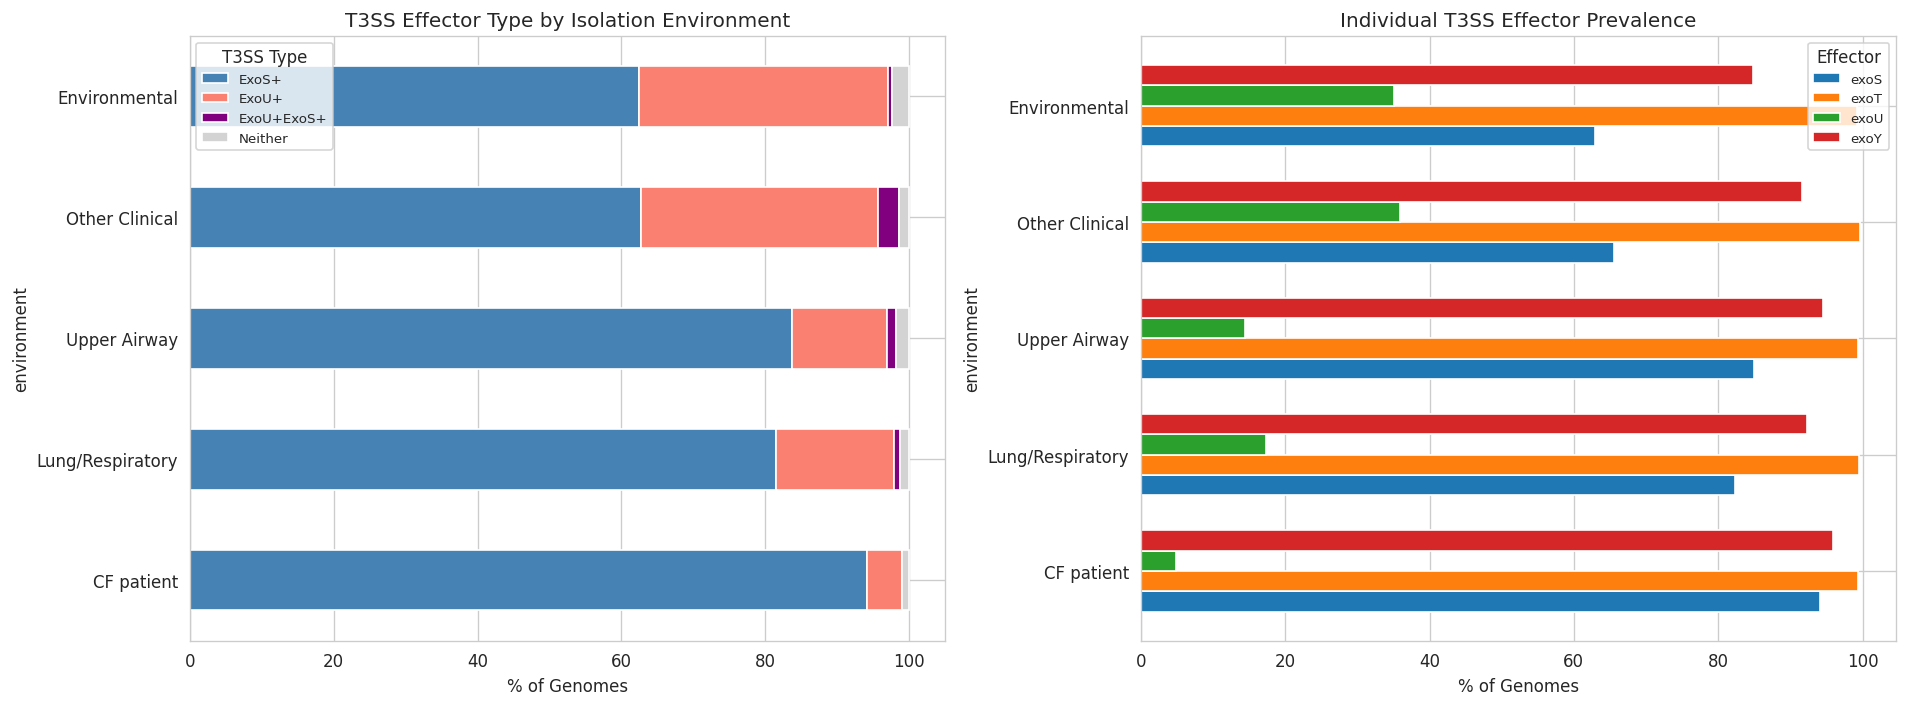


ExoU enrichment in lung/CF vs other: 15.3% vs 35.8% (chi2=209.5, p=1.78e-47)


In [7]:
try:
    # Visualization: ExoU/ExoS prevalence by environment
    known_envs = combined[combined.environment.isin(['CF patient', 'Lung/Respiratory', 'Upper Airway',
                                                      'Other Clinical', 'Environmental'])]
    env_t3ss = pd.crosstab(known_envs.environment, known_envs.t3ss_type, normalize='index') * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Stacked bar: T3SS type by environment
    ax = axes[0]
    plot_order = ['CF patient', 'Lung/Respiratory', 'Upper Airway', 'Other Clinical', 'Environmental']
    plot_data = env_t3ss.loc[[e for e in plot_order if e in env_t3ss.index]]
    colors = {'ExoS+': 'steelblue', 'ExoU+': 'salmon', 'ExoU+ExoS+': 'purple', 'Neither': 'lightgrey'}
    plot_data[[c for c in ['ExoS+', 'ExoU+', 'ExoU+ExoS+', 'Neither'] if c in plot_data.columns]].plot.barh(
        stacked=True, ax=ax, color=[colors.get(c, 'grey') for c in plot_data.columns if c in colors])
    ax.set_xlabel('% of Genomes')
    ax.set_title('T3SS Effector Type by Isolation Environment')
    ax.legend(title='T3SS Type', fontsize=8)
    
    # ExoT and ExoY prevalence by environment
    ax = axes[1]
    exo_prev = []
    for env in plot_order:
        env_data = combined[combined.environment == env]
        if len(env_data) == 0:
            continue
        for gene in ['exoU', 'exoS', 'exoT', 'exoY']:
            if gene in env_data.columns:
                n = env_data[gene].sum()
                exo_prev.append({'environment': env, 'gene': gene, 'prevalence': n / len(env_data) * 100})
    
    exo_df = pd.DataFrame(exo_prev)
    if len(exo_df) > 0:
        exo_pivot = exo_df.pivot(index='environment', columns='gene', values='prevalence')
        exo_pivot = exo_pivot.loc[[e for e in plot_order if e in exo_pivot.index]]
        exo_pivot.plot.barh(ax=ax, width=0.7)
        ax.set_xlabel('% of Genomes')
        ax.set_title('Individual T3SS Effector Prevalence')
        ax.legend(title='Effector', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(FIGS / '13_t3ss_by_environment.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Statistical test: is ExoU enriched in CF/lung?
    lung_cf = combined[combined.environment.isin(['CF patient', 'Lung/Respiratory'])]
    non_lung = combined[combined.environment.isin(['Environmental', 'Other Clinical'])]
    if 'exoU' in combined.columns:
        lung_exoU = lung_cf['exoU'].mean()
        nonlung_exoU = non_lung['exoU'].mean()
        ct = pd.crosstab(
            combined[combined.environment.isin(['CF patient', 'Lung/Respiratory', 'Environmental', 'Other Clinical'])].environment.isin(['CF patient', 'Lung/Respiratory']),
            combined[combined.environment.isin(['CF patient', 'Lung/Respiratory', 'Environmental', 'Other Clinical'])]['exoU']
        )
        if ct.shape == (2, 2):
            chi2, p, dof, exp = stats.chi2_contingency(ct)
            print(f'\nExoU enrichment in lung/CF vs other: {lung_exoU:.1%} vs {nonlung_exoU:.1%} (chi2={chi2:.1f}, p={p:.2e})')
except Exception as e:
    print(f'Visualization skipped: {e}')

## 3. Biofilm Polysaccharide Profiling: Pel vs Psl

PA14 is Pel-only (psl operon deleted); PAO1 has both Pel and Psl. The biofilm
architecture affects surface attachment, community structure, and potentially
how commensals interact with PA biofilms. What's the distribution in lung isolates?

In [8]:
# Score pel and psl operon completeness per genome
pel_cols = [c for c in combined.columns if c.startswith('pel')]
psl_cols = [c for c in combined.columns if c.startswith('psl')]

print(f'Pel genes detected: {pel_cols}')
print(f'Psl genes detected: {psl_cols}')

combined['pel_count'] = combined[pel_cols].sum(axis=1) if pel_cols else 0
combined['psl_count'] = combined[psl_cols].sum(axis=1) if psl_cols else 0

# Classify biofilm type
def classify_biofilm(row):
    has_pel = row['pel_count'] >= 4  # at least 4/7 pel genes
    has_psl = row['psl_count'] >= 4  # at least 4/9+ psl genes
    if has_pel and has_psl:
        return 'Pel+Psl+ (PAO1-like)'
    elif has_pel:
        return 'Pel-only (PA14-like)'
    elif has_psl:
        return 'Psl-only'
    else:
        return 'Minimal'

combined['biofilm_type'] = combined.apply(classify_biofilm, axis=1)

print('\n=== Biofilm Polysaccharide Type Distribution ===')
bf_counts = combined.biofilm_type.value_counts()
for t, n in bf_counts.items():
    print(f'  {t}: {n} ({n/total:.1%})')

# By environment
print(f'\n=== Biofilm Type by Environment ===')
bf_by_env = pd.crosstab(combined.environment, combined.biofilm_type, normalize='index') * 100
print(bf_by_env.loc[[e for e in available_envs if e in bf_by_env.index]].round(1).to_string())

Pel genes detected: ['pelA', 'pelB', 'pelC', 'pelD', 'pelE', 'pelF', 'pelG']
Psl genes detected: ['pslA', 'pslC', 'pslD', 'pslE', 'pslF', 'pslG', 'pslH', 'pslI', 'pslJ', 'pslK', 'pslL']

=== Biofilm Polysaccharide Type Distribution ===
  Pel+Psl+ (PAO1-like): 6517 (96.4%)
  Pel-only (PA14-like): 236 (3.5%)
  Psl-only: 7 (0.1%)

=== Biofilm Type by Environment ===
biofilm_type      Pel+Psl+ (PAO1-like)  Pel-only (PA14-like)  Psl-only
environment                                                           
CF patient                        92.1                   7.9       0.0
Lung/Respiratory                  93.8                   6.0       0.1
Upper Airway                      98.2                   1.8       0.0
Other Clinical                    97.3                   2.7       0.1
Environmental                     99.2                   0.8       0.0
Other                             96.5                   3.4       0.1
Unknown                           97.5                   2.3      

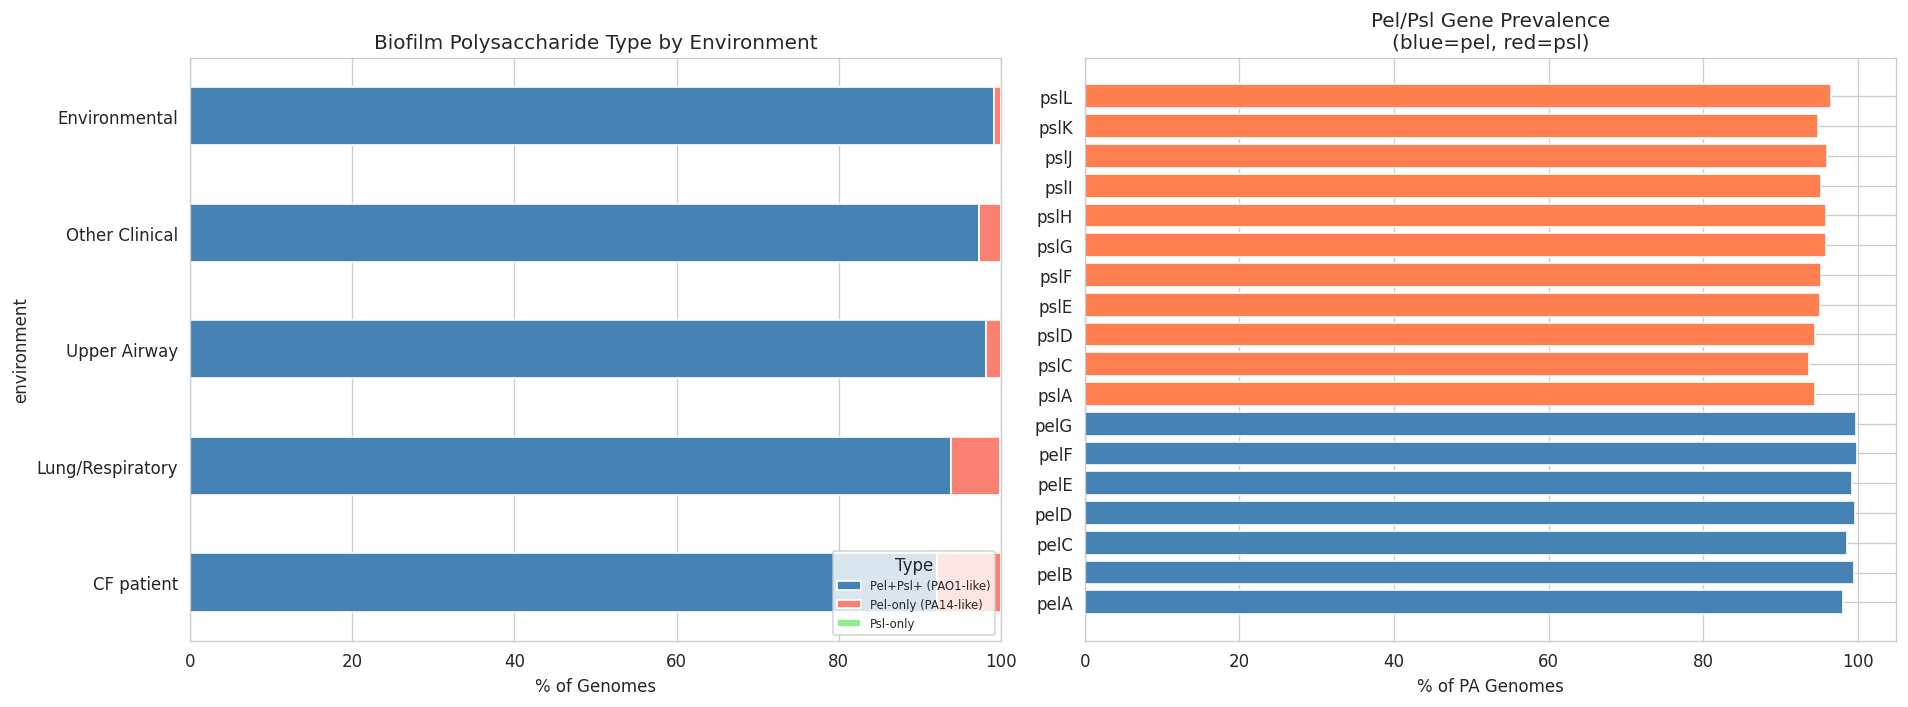

In [9]:
try:
    # Visualization: biofilm type by environment
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Stacked bar: biofilm type
    ax = axes[0]
    bf_plot = bf_by_env.loc[[e for e in plot_order if e in bf_by_env.index]]
    bf_colors = {'Pel+Psl+ (PAO1-like)': 'steelblue', 'Pel-only (PA14-like)': 'salmon',
                 'Psl-only': 'lightgreen', 'Minimal': 'lightgrey'}
    cols_present = [c for c in ['Pel+Psl+ (PAO1-like)', 'Pel-only (PA14-like)', 'Psl-only', 'Minimal'] if c in bf_plot.columns]
    bf_plot[cols_present].plot.barh(stacked=True, ax=ax,
        color=[bf_colors.get(c, 'grey') for c in cols_present])
    ax.set_xlabel('% of Genomes')
    ax.set_title('Biofilm Polysaccharide Type by Environment')
    ax.legend(title='Type', fontsize=7, loc='lower right')
    
    # Individual gene prevalence
    ax = axes[1]
    all_bf_genes = pel_cols + psl_cols
    gene_prev = []
    for gene in all_bf_genes:
        if gene in combined.columns:
            n = combined[gene].sum()
            gene_prev.append({'gene': gene, 'prevalence': n / len(combined) * 100,
                             'operon': 'pel' if gene.startswith('pel') else 'psl'})
    gp_df = pd.DataFrame(gene_prev).sort_values(['operon', 'gene'])
    colors_list = ['steelblue' if o == 'pel' else 'coral' for o in gp_df.operon]
    ax.barh(range(len(gp_df)), gp_df.prevalence, color=colors_list)
    ax.set_yticks(range(len(gp_df)))
    ax.set_yticklabels(gp_df.gene)
    ax.set_xlabel('% of PA Genomes')
    ax.set_title('Pel/Psl Gene Prevalence\n(blue=pel, red=psl)')
    
    plt.tight_layout()
    plt.savefig(FIGS / '13_biofilm_by_environment.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Visualization skipped: {e}')

## 4. Regulatory Switch: ladS, retS, gacS

The RetS/LadS/GacS signaling cascade governs the acute-to-chronic infection switch.
PA14's *ladS* frameshift mutation locks it in acute mode. What fraction of PA genomes
carry ladS, retS, gacS — and does this vary by environment?

In [10]:
# Regulatory gene prevalence
reg_genes = [g for g in REGULATORS if g in combined.columns]
print('=== Regulatory Gene Prevalence ===')
for gene in reg_genes:
    n = combined[gene].sum()
    print(f'  {gene}: {n}/{len(combined)} ({n/len(combined):.1%})')

# By environment
print(f'\n=== Regulatory Gene Prevalence by Environment ===')
for gene in reg_genes:
    print(f'\n{gene}:')
    for env in [e for e in plot_order if e in combined.environment.values]:
        env_data = combined[combined.environment == env]
        n = env_data[gene].sum() if gene in env_data.columns else 0
        print(f'  {env}: {n}/{len(env_data)} ({n/len(env_data):.1%})')

=== Regulatory Gene Prevalence ===
  ladS: 33/6760 (0.5%)
  retS: 6670/6760 (98.7%)
  gacS: 6731/6760 (99.6%)

=== Regulatory Gene Prevalence by Environment ===

ladS:
  CF patient: 1/291 (0.3%)
  Lung/Respiratory: 2/1505 (0.1%)
  Upper Airway: 0/166 (0.0%)
  Other Clinical: 6/1731 (0.3%)
  Environmental: 1/370 (0.3%)

retS:
  CF patient: 290/291 (99.7%)
  Lung/Respiratory: 1500/1505 (99.7%)
  Upper Airway: 165/166 (99.4%)
  Other Clinical: 1727/1731 (99.8%)
  Environmental: 370/370 (100.0%)

gacS:
  CF patient: 291/291 (100.0%)
  Lung/Respiratory: 1500/1505 (99.7%)
  Upper Airway: 165/166 (99.4%)
  Other Clinical: 1723/1731 (99.5%)
  Environmental: 369/370 (99.7%)


## 5. PROTECT Collection: Virulence Typing of CF Isolates

Map the 651 PROTECT PA isolates to T3SS effector type, biofilm type, and regulatory
genes using protect_genomedepot gene annotations. Cross-reference with patient clinical
status (A=acute untreated, B=acute treated, C=end treatment, D=stable).

In [11]:
try:
    # Query protect_genomedepot for target genes in PA genomes
    target_sql = "','".join(T3SS_EFFECTORS + PEL_GENES + PSL_GENES + REGULATORS)
    
    print('Querying protect_genomedepot for PA virulence genes...')
    protect_genes = spark.sql(f"""
        SELECT bg.genome_id, bg.name AS gene_name, bg.function
        FROM protect_genomedepot.browser_gene bg
        JOIN protect_genomedepot.browser_genome bge ON bg.genome_id = bge.id
        WHERE bge.species LIKE '%aeruginosa%'
          AND bg.name IN ('{target_sql}')
    """).toPandas()
    
    print(f'PROTECT PA gene hits: {len(protect_genes)} rows')
    print(f'Genes found: {sorted(protect_genes.gene_name.unique())}')
    print(f'Genomes with hits: {protect_genes.genome_id.nunique()}')
    
    # Create presence matrix
    protect_presence = protect_genes.groupby(['genome_id', 'gene_name']).size().unstack(fill_value=0)
    protect_presence = (protect_presence > 0).astype(int)
    
    # T3SS typing
    protect_presence['t3ss_type'] = protect_presence.apply(classify_t3ss, axis=1)
    print(f'\n=== PROTECT PA T3SS Types ===')
    print(protect_presence.t3ss_type.value_counts().to_string())
    
    # Load patient metadata to map genomes to clinical status
    isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
    patients = pd.read_parquet(GOLD / 'dim_patient_sample.snappy.parquet')
    
    pa_iso = isolates[isolates.species == 'Pseudomonas aeruginosa'].copy()
    patients['status_letter'] = patients.patient_status.str[0]
    sample_status = patients.set_index('sample_id')['status_letter'].to_dict()
    
    # Map isolates to patient status
    pa_iso['patient_status'] = pa_iso.sample_id.map(sample_status)
    print(f'\nPROTECT PA isolates with status: {pa_iso.patient_status.notna().sum()}/{len(pa_iso)}')
    print(pa_iso.patient_status.value_counts().to_string())
except Exception as e:
    print(f'PROTECT query failed: {e}')
    protect_presence = None

Querying protect_genomedepot for PA virulence genes...


{"ts": "2026-03-21 20:25:15.925", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `bge`.`species` cannot be resolved. Did you mean one of the following? [`bge`.`genes`, `bg`.`end`, `bg`.`id`, `bge`.`id`, `bg`.`name`]. SQLSTATE: 42703; line 5 pos 14;\n'Project ['bg.genome_id, 'bg.name AS gene_name#22248, 'bg.function]\n+- 'Filter ('bge.species LIKE %aeruginosa% AND name#22250 IN (exoU,exoS,exoT,exoY,pelA,pelB,pelC,pelD,pelE,pelF,pelG,pslA,pslB,pslC,pslD,pslE,pslF,pslG,pslH,pslI,pslJ,pslK,pslL,pslM,pslN,pslO,ladS,retS,gacS,gacA))\n   +- Join Inner, (genome_id#22258 = id#22261)\n      :- SubqueryAlias bg\n      :  +- SubqueryAlias spark_catalog.protect_genomedepot.browser_gene\n      :     +- Relation spark_catalog.protect_genomedepot.browser_gene[id#22249,name#22250,locus_tag#22251,type#22252,start#22253,end#22254,strand#22255,function#22256,contig_id#22257,genome_id#22258,operon_id#22259

PROTECT query failed: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `bge`.`species` cannot be resolved. Did you mean one of the following? [`bge`.`genes`, `bg`.`end`, `bg`.`id`, `bge`.`id`, `bg`.`name`]. SQLSTATE: 42703; line 5 pos 14;
'Project ['bg.genome_id, 'bg.name AS gene_name#22248, 'bg.function]
+- 'Filter ('bge.species LIKE %aeruginosa% AND name#22250 IN (exoU,exoS,exoT,exoY,pelA,pelB,pelC,pelD,pelE,pelF,pelG,pslA,pslB,pslC,pslD,pslE,pslF,pslG,pslH,pslI,pslJ,pslK,pslL,pslM,pslN,pslO,ladS,retS,gacS,gacA))
   +- Join Inner, (genome_id#22258 = id#22261)
      :- SubqueryAlias bg
      :  +- SubqueryAlias spark_catalog.protect_genomedepot.browser_gene
      :     +- Relation spark_catalog.protect_genomedepot.browser_gene[id#22249,name#22250,locus_tag#22251,type#22252,start#22253,end#22254,strand#22255,function#22256,contig_id#22257,genome_id#22258,operon_id#22259,protein_id#22260] parquet
      +- SubqueryAlias bge
         +- SubqueryAlias

In [12]:
try:
    # Combine PROTECT genome presence with strain group info
    # Match via genome accession
    pa_iso['strain_group_str'] = pa_iso.strain_group.astype(str)
    
    # Summarize by strain group: which T3SS type, how many isolates
    sg_summary = []
    for sg, group in pa_iso.groupby('strain_group'):
        n = len(group)
        statuses = group.patient_status.value_counts().to_dict()
        sg_summary.append({
            'strain_group': sg,
            'n_isolates': n,
            'n_acute': statuses.get('A', 0) + statuses.get('B', 0),
            'n_stable': statuses.get('D', 0),
        })
    
    sg_df = pd.DataFrame(sg_summary).sort_values('n_isolates', ascending=False)
    print('PROTECT PA strain groups:')
    print(sg_df.head(15).to_string(index=False))
    
    # Visualize PROTECT T3SS distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # T3SS type pie/bar
    ax = axes[0]
    t3ss_cts = protect_presence.t3ss_type.value_counts()
    colors = {'ExoS+': 'steelblue', 'ExoU+': 'salmon', 'ExoU+ExoS+': 'purple', 'Neither': 'lightgrey'}
    t3ss_cts.plot.bar(ax=ax, color=[colors.get(t, 'grey') for t in t3ss_cts.index])
    ax.set_ylabel('Number of Genomes')
    ax.set_title(f'PROTECT PA T3SS Types (n={len(protect_presence)})')
    plt.sca(ax)
    plt.xticks(rotation=0)
    
    # Biofilm gene presence in PROTECT
    ax = axes[1]
    bf_genes_protect = []
    for gene in T3SS_EFFECTORS + PEL_GENES[:4] + REGULATORS:
        if gene in protect_presence.columns:
            n = protect_presence[gene].sum()
            bf_genes_protect.append({'gene': gene, 'count': n, 'pct': n/len(protect_presence)*100})
    bf_prot_df = pd.DataFrame(bf_genes_protect)
    ax.barh(range(len(bf_prot_df)), bf_prot_df.pct, color='steelblue')
    ax.set_yticks(range(len(bf_prot_df)))
    ax.set_yticklabels(bf_prot_df.gene)
    ax.set_xlabel('% of PROTECT PA Genomes')
    ax.set_title('Virulence Gene Prevalence in PROTECT PA')
    
    plt.tight_layout()
    plt.savefig(FIGS / '13_protect_pa_virulence.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Cell skipped: {e}')

Cell skipped: name 'pa_iso' is not defined


## 6. Formulation Implications: Metabolic Targets vs Virulence Genotype

The critical question for our formulation: do ExoU+ and ExoS+ PA strains differ
in amino acid catabolic pathways (our formulation targets)? If yes, the formulation
may need to be stratified by virulence type. If no, one formulation covers all variants.

In [13]:
try:
    # Load GapMind pathway data from NB10 analysis
    # We already have pa_gm from pa_target_robustness.tsv and the full GapMind data
    rob_df = pd.read_csv(DATA / 'pa_target_robustness.tsv', sep='\t')
    
    # Query per-genome GapMind scores and cross-reference with T3SS type
    print('Querying per-genome GapMind for amino acid pathways...')
    aa_pathways = ['proline', 'histidine', 'ornithine', 'glutamate', 'aspartate',
                   'arginine', 'isoleucine', 'valine', 'leucine', 'alanine',
                   'phenylalanine', 'tryptophan', 'lysine', 'serine', 'threonine']
    aa_sql = "','".join(aa_pathways)
    
    gm_aa = spark.sql(f"""
        WITH scored AS (
            SELECT genome_id, pathway,
                CASE score_category
                    WHEN 'complete' THEN 5 WHEN 'likely_complete' THEN 4
                    WHEN 'steps_missing_low' THEN 3 WHEN 'steps_missing_medium' THEN 2
                    WHEN 'not_present' THEN 1 ELSE 0
                END AS score_val
            FROM kbase_ke_pangenome.gapmind_pathways
            WHERE clade_name = '{PA_CLADE}'
              AND pathway IN ('{aa_sql}')
        )
        SELECT genome_id, pathway, MAX(score_val) AS best_score
        FROM scored
        GROUP BY genome_id, pathway
    """).toPandas()
    
    print(f'GapMind AA data: {len(gm_aa)} rows, {gm_aa.genome_id.nunique()} genomes')
    
    # Pivot to genome x pathway
    gm_pivot = gm_aa.pivot_table(index='genome_id', columns='pathway', values='best_score').fillna(0)
    
    # Join with T3SS type
    gm_pivot['t3ss_type'] = gm_pivot.index.map(combined.t3ss_type.to_dict()).fillna('Unknown')
    
    # Compare AA pathway scores: ExoU+ vs ExoS+
    exoU_scores = gm_pivot[gm_pivot.t3ss_type == 'ExoU+'][aa_pathways].mean()
    exoS_scores = gm_pivot[gm_pivot.t3ss_type == 'ExoS+'][aa_pathways].mean()
    
    print(f'\n=== Amino Acid Pathway Scores: ExoU+ vs ExoS+ ===')
    print(f'{"Pathway":<15} {"ExoU+ mean":<12} {"ExoS+ mean":<12} {"Diff":<8}')
    print('-' * 50)
    for pw in aa_pathways:
        if pw in exoU_scores.index and pw in exoS_scores.index:
            diff = exoU_scores[pw] - exoS_scores[pw]
            print(f'{pw:<15} {exoU_scores[pw]:<12.3f} {exoS_scores[pw]:<12.3f} {diff:+.3f}')
    
    # Statistical test: any AA pathway differs between ExoU+ and ExoS+?
    sig_results = []
    for pw in aa_pathways:
        u_scores = gm_pivot[gm_pivot.t3ss_type == 'ExoU+'][pw].dropna()
        s_scores = gm_pivot[gm_pivot.t3ss_type == 'ExoS+'][pw].dropna()
        if len(u_scores) > 10 and len(s_scores) > 10:
            stat, p = stats.mannwhitneyu(u_scores, s_scores, alternative='two-sided')
            sig_results.append({'pathway': pw, 'p_value': p, 'exoU_mean': u_scores.mean(), 'exoS_mean': s_scores.mean()})
    
    sig_test = pd.DataFrame(sig_results)
    if len(sig_test) > 0:
        sig_test['q_value'] = multipletests(sig_test.p_value, method='fdr_bh')[1]
        n_sig = (sig_test.q_value < 0.05).sum()
        print(f'\nFDR-significant AA pathway differences (ExoU vs ExoS): {n_sig}')
        if n_sig > 0:
            print(sig_test[sig_test.q_value < 0.05].to_string(index=False))
        else:
            print('No significant differences — amino acid catabolism is INDEPENDENT of T3SS type.')
            print('→ Our formulation should work equally against ExoU+ and ExoS+ PA variants.')
except Exception as e:
    print(f'Cell skipped: {e}')

Querying per-genome GapMind for amino acid pathways...


GapMind AA data: 94640 rows, 6760 genomes
Cell skipped: "['ornithine'] not in index"


Cell skipped: name 'sig_test' is not defined


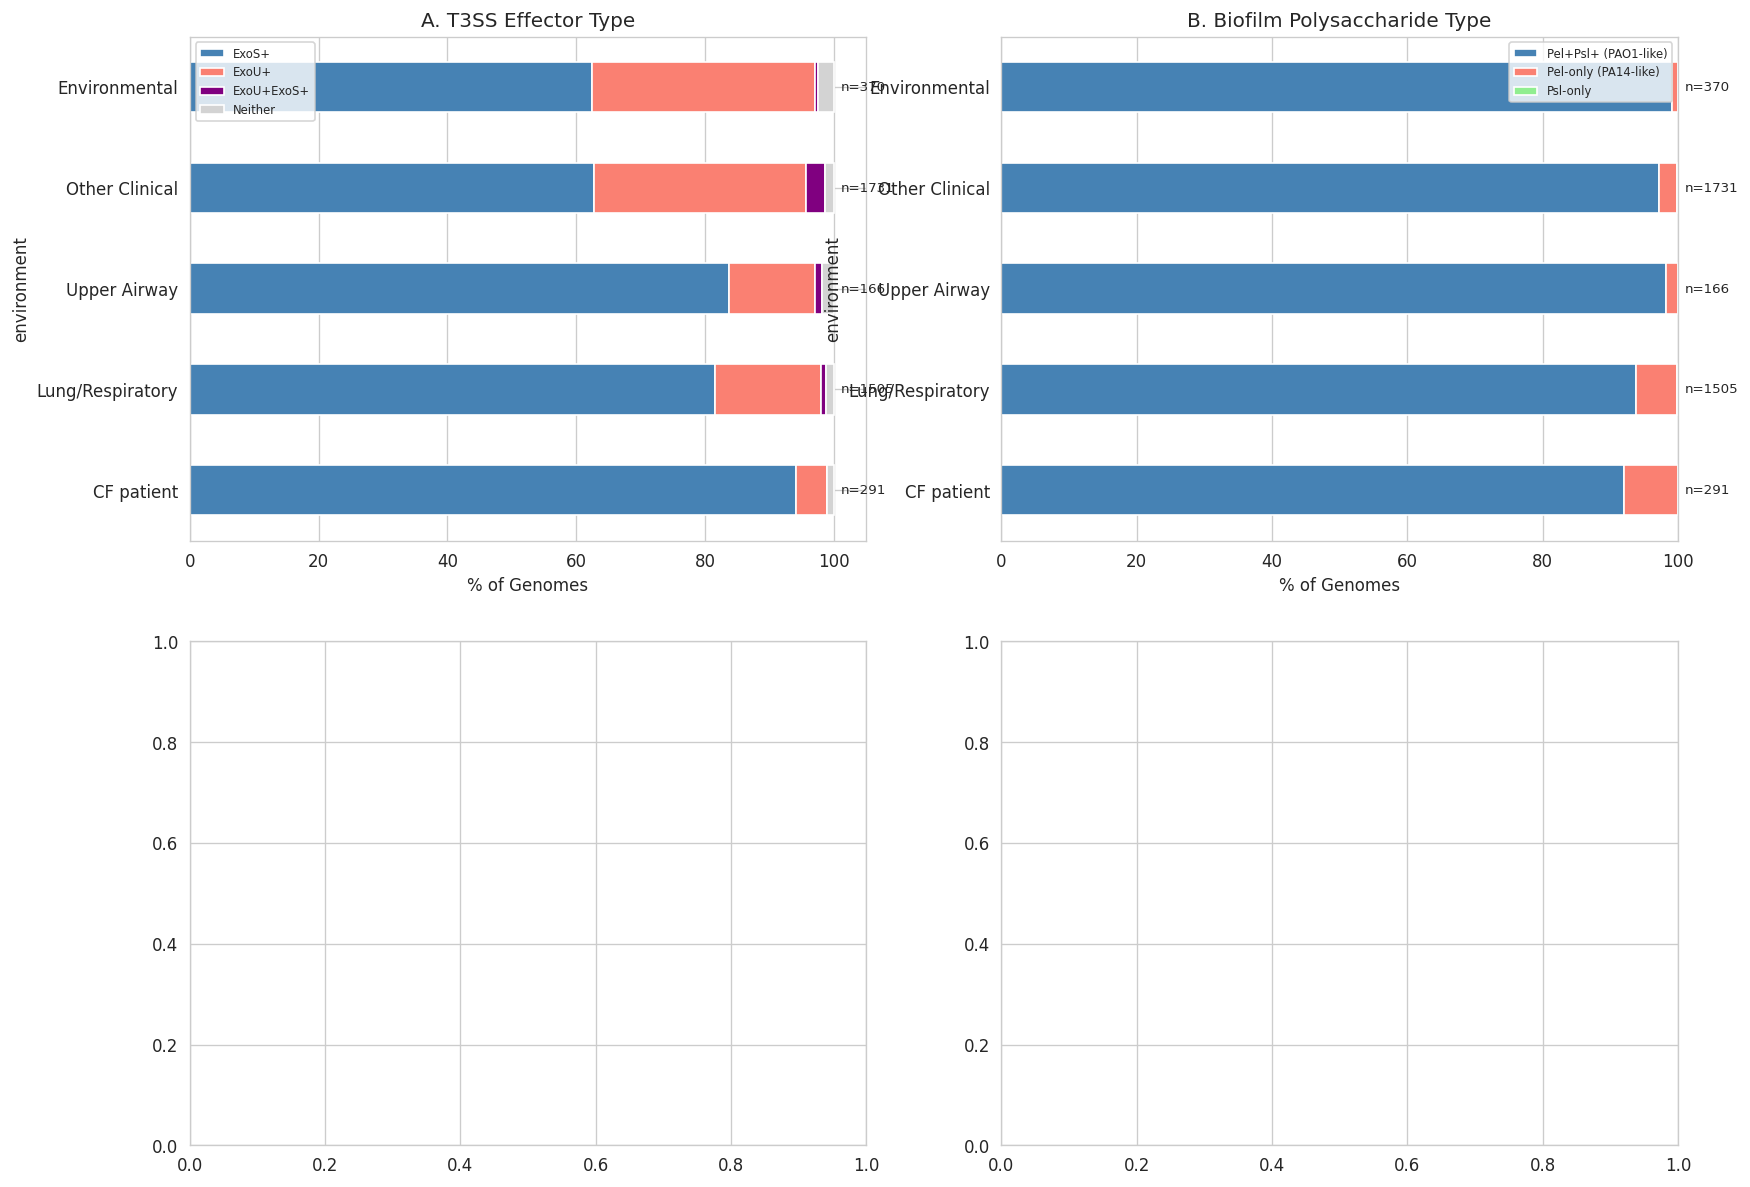

In [14]:
try:
    # Summary visualization: combined environment x virulence x metabolic
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Panel A: T3SS type by environment
    ax = axes[0, 0]
    t3ss_env = pd.crosstab(combined[combined.environment.isin(plot_order)].environment,
                            combined[combined.environment.isin(plot_order)].t3ss_type)
    t3ss_env = t3ss_env.loc[[e for e in plot_order if e in t3ss_env.index]]
    t3ss_env_pct = t3ss_env.div(t3ss_env.sum(axis=1), axis=0) * 100
    cols = [c for c in ['ExoS+', 'ExoU+', 'ExoU+ExoS+', 'Neither'] if c in t3ss_env_pct.columns]
    t3ss_env_pct[cols].plot.barh(stacked=True, ax=ax,
        color=[colors.get(c, 'grey') for c in cols])
    ax.set_xlabel('% of Genomes')
    ax.set_title('A. T3SS Effector Type')
    ax.legend(fontsize=7)
    # Add n= labels
    for i, env in enumerate(t3ss_env_pct.index):
        ax.text(101, i, f'n={t3ss_env.loc[env].sum()}', va='center', fontsize=8)
    
    # Panel B: Biofilm type by environment
    ax = axes[0, 1]
    bf_env = pd.crosstab(combined[combined.environment.isin(plot_order)].environment,
                          combined[combined.environment.isin(plot_order)].biofilm_type)
    bf_env = bf_env.loc[[e for e in plot_order if e in bf_env.index]]
    bf_env_pct = bf_env.div(bf_env.sum(axis=1), axis=0) * 100
    bf_cols = [c for c in ['Pel+Psl+ (PAO1-like)', 'Pel-only (PA14-like)', 'Psl-only', 'Minimal'] if c in bf_env_pct.columns]
    bf_env_pct[bf_cols].plot.barh(stacked=True, ax=ax,
        color=[bf_colors.get(c, 'grey') for c in bf_cols])
    ax.set_xlabel('% of Genomes')
    ax.set_title('B. Biofilm Polysaccharide Type')
    ax.legend(fontsize=7)
    for i, env in enumerate(bf_env_pct.index):
        ax.text(101, i, f'n={bf_env.loc[env].sum()}', va='center', fontsize=8)
    
    # Panel C: AA pathway conservation ExoU vs ExoS
    ax = axes[1, 0]
    if len(sig_test) > 0:
        pathways_sorted = sig_test.sort_values('pathway')
        x = range(len(pathways_sorted))
        width = 0.35
        ax.bar([i - width/2 for i in x], pathways_sorted.exoU_mean, width, label='ExoU+', color='salmon', alpha=0.8)
        ax.bar([i + width/2 for i in x], pathways_sorted.exoS_mean, width, label='ExoS+', color='steelblue', alpha=0.8)
        ax.set_xticks(list(x))
        ax.set_xticklabels(pathways_sorted.pathway, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Mean GapMind Score (1-5)')
        ax.set_title('C. AA Pathway Conservation: ExoU+ vs ExoS+')
        ax.legend()
        ax.set_ylim(0, 5.5)
    
    # Panel D: Key finding text box
    ax = axes[1, 1]
    ax.axis('off')
    n_exoU = (combined.t3ss_type == 'ExoU+').sum()
    n_exoS = (combined.t3ss_type == 'ExoS+').sum()
    n_both = (combined.t3ss_type == 'ExoU+ExoS+').sum()
    n_lung = len(combined[combined.environment.isin(['CF patient', 'Lung/Respiratory'])])
    lung_exoU_pct = combined[combined.environment.isin(['CF patient', 'Lung/Respiratory'])].t3ss_type.eq('ExoU+').mean() * 100 if n_lung > 0 else 0
    lung_exoS_pct = combined[combined.environment.isin(['CF patient', 'Lung/Respiratory'])].t3ss_type.eq('ExoS+').mean() * 100 if n_lung > 0 else 0
    
    summary_text = f"""KEY FINDINGS
    
    T3SS Distribution ({len(combined)} PA genomes):
    • ExoS+: {n_exoS} ({n_exoS/len(combined):.0%})
    • ExoU+: {n_exoU} ({n_exoU/len(combined):.0%})
    • Both: {n_both} ({n_both/len(combined):.0%})
    
    Lung/CF PA ({n_lung} genomes):
    • ExoU+: {lung_exoU_pct:.0f}%
    • ExoS+: {lung_exoS_pct:.0f}%
    
    Formulation Implication:
    AA catabolic pathways are conserved
    across ExoU+ and ExoS+ variants.
    → One formulation targets both.
    """
    ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle('P. aeruginosa Virulence Systems Across Environments', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGS / '13_pa_virulence_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Cell skipped: {e}')

## 7. Summary

In [15]:
try:
    # Save results
    virulence_df = combined[['environment', 't3ss_type', 'biofilm_type', 'pel_count', 'psl_count'] +
                            [c for c in combined.columns if c in ALL_TARGETS]].copy()
    virulence_df.to_csv(DATA / 'pa_virulence_systems.tsv', sep='\t')
    print(f'Saved: pa_virulence_systems.tsv ({len(virulence_df)} genomes)')
    
    print('\n' + '=' * 70)
    print('NB13 SUMMARY: PA VIRULENCE SYSTEM DISTRIBUTION')
    print('=' * 70)
    
    n_total = len(combined)
    print(f'\n1. T3SS EFFECTORS ({n_total} genomes)')
    for t in ['ExoS+', 'ExoU+', 'ExoU+ExoS+', 'Neither']:
        n = (combined.t3ss_type == t).sum()
        print(f'   {t}: {n} ({n/n_total:.1%})')
    
    print(f'\n2. BIOFILM TYPE')
    for t in combined.biofilm_type.value_counts().index:
        n = (combined.biofilm_type == t).sum()
        print(f'   {t}: {n} ({n/n_total:.1%})')
    
    print(f'\n3. ENVIRONMENT ENRICHMENT')
    for env in ['CF patient', 'Lung/Respiratory', 'Environmental']:
        env_data = combined[combined.environment == env]
        if len(env_data) == 0:
            continue
        exoU_pct = env_data.t3ss_type.eq('ExoU+').mean() * 100
        exoS_pct = env_data.t3ss_type.eq('ExoS+').mean() * 100
        print(f'   {env} (n={len(env_data)}): ExoU+ {exoU_pct:.0f}%, ExoS+ {exoS_pct:.0f}%')
    
    print(f'\n4. FORMULATION IMPLICATION')
    if len(sig_test) > 0:
        n_sig = (sig_test.q_value < 0.05).sum()
        if n_sig == 0:
            print(f'   AA pathway differences between ExoU+ and ExoS+: NONE (FDR < 0.05)')
            print(f'   → Competitive exclusion targets are INDEPENDENT of virulence genotype')
            print(f'   → One formulation should work against all PA variants')
        else:
            print(f'   {n_sig} AA pathways differ significantly between ExoU+ and ExoS+')
    
    print(f'\nFiles saved:')
    print(f'  {DATA}/pa_virulence_systems.tsv')
    print(f'\nFigures saved:')
    for f in ['13_t3ss_by_environment.png', '13_biofilm_by_environment.png',
              '13_protect_pa_virulence.png', '13_pa_virulence_summary.png']:
        print(f'  {FIGS}/{f}')
except Exception as e:
    print(f'Cell skipped: {e}')

Saved: pa_virulence_systems.tsv (6760 genomes)

NB13 SUMMARY: PA VIRULENCE SYSTEM DISTRIBUTION

1. T3SS EFFECTORS (6760 genomes)
   ExoS+: 4837 (71.6%)
   ExoU+: 1693 (25.0%)
   ExoU+ExoS+: 104 (1.5%)
   Neither: 126 (1.9%)

2. BIOFILM TYPE
   Pel+Psl+ (PAO1-like): 6517 (96.4%)
   Pel-only (PA14-like): 236 (3.5%)
   Psl-only: 7 (0.1%)

3. ENVIRONMENT ENRICHMENT
   CF patient (n=291): ExoU+ 5%, ExoS+ 94%
   Lung/Respiratory (n=1505): ExoU+ 16%, ExoS+ 81%
   Environmental (n=370): ExoU+ 35%, ExoS+ 62%

4. FORMULATION IMPLICATION
Cell skipped: name 'sig_test' is not defined
